# LangGraph Starter — State, Reducers, and an LLM Node

This is the simplest possible LangGraph notebook in this series. Before the agentic
RAG notebooks (`1_Agentic_RAG.ipynb`, `2_ReAct_MultiHop_Agentic_RAG.ipynb`), it's worth
seeing the two ideas those notebooks build on, with nothing else in the way:

1. **State** — the shared dict-like object that flows through every node in the graph.
2. **Reducers** — the rule LangGraph uses to *combine* a node's return value with the
   existing state, instead of blindly overwriting it.

We'll build two tiny graphs:

- **Graph A**: one node that calls an LLM. This shows the basic node → edge → compile → run loop.
- **Graph B**: two nodes that run in parallel and both write to the same state key. This
  is the smallest example that actually *needs* a reducer, so you can see why they exist.

## 1. Imports

- `dotenv` — loads the `.env` file so the Groq API key isn't hardcoded
- `langchain_groq` — the LLM client
- `langchain_core.messages` — `HumanMessage` / message types
- `langgraph.graph` — `StateGraph`, `START`, `END`, and `add_messages` (the built-in reducer for chat history)
- `operator` — gives us `operator.add`, a second reducer we'll use for a plain list
- `IPython.display` — to render the compiled graph as an image

In [1]:
import os
import operator
from typing import Annotated, List

from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

## 2. Load the API key

Same as the other notebooks: `load_dotenv()` reads a local `.env` file, and
`os.getenv(...)` pulls `GROQ_API_KEY` out as a Python string.

In [2]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

## 3. Initialize the LLM

One shared client, `groq_llm`, using Groq's `openai/gpt-oss-120b` model.
`temperature=0` keeps answers deterministic, which makes debugging easier.

In [3]:
groq_llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="openai/gpt-oss-120b",
    temperature=0
)

## Graph A — one node, one LLM call

### 4. Define the state

Every LangGraph graph needs a `State` — the object that gets passed between nodes.
Here it has one field, `messages`, which holds the running chat history.

The important part is the `Annotated[..., add_messages]` type. Without it, if a node
returned `{"messages": [new_message]}`, LangGraph would *replace* the whole list with
just that one new message. `add_messages` is a **reducer**: a function that tells
LangGraph "when a node updates this key, append to the existing list instead of
overwriting it, and merge by message ID if it's an edit." It's the standard reducer
for chat state, which is why you'll see it in almost every LangGraph example.

In [4]:
class State(BaseModel):
    messages: Annotated[List[BaseMessage], add_messages] = []

### 5. Define the node

A node is just a Python function that takes the state and returns a partial update.
This one sends the current message history to the LLM and returns its reply. Because
`messages` uses the `add_messages` reducer, we only need to return the *new* message —
LangGraph takes care of appending it to the history.

In [5]:
def chatbot(state: State):
    response = groq_llm.invoke(state.messages)
    return {"messages": [response]}

### 6. Assemble and compile the graph

A one-node graph: `START` feeds into `chatbot`, and `chatbot` feeds into `END`.

In [6]:
graph_a_builder = StateGraph(State)

graph_a_builder.add_node("chatbot", chatbot)
graph_a_builder.add_edge(START, "chatbot")
graph_a_builder.add_edge("chatbot", END)

graph_a = graph_a_builder.compile()

### 7. Visualize

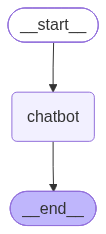

In [7]:
display(Image(graph_a.get_graph().draw_mermaid_png()))

### 8. Run it

In [8]:
result = graph_a.invoke({"messages": [HumanMessage(content="What is LangGraph, in one sentence?")]})

for message in result["messages"]:
    print(type(message).__name__ + ":", message.content)

HumanMessage: What is LangGraph, in one sentence?
AIMessage: LangGraph is an open‑source Python library that enables developers to build, visualize, and orchestrate complex, state‑driven workflows of LLM‑powered agents and tools as directed graphs.


## Graph B — why reducers actually matter

Graph A only ever had one node writing to `messages`, so it's easy to miss what the
reducer is doing for you. This graph makes it obvious: two nodes, `node_a` and
`node_b`, run **in parallel** and both write to the *same* state key, `log`.

- If `log` had no reducer, LangGraph wouldn't know which node's write should "win" and
  raises an error when two branches update the same key in the same step.
- With `operator.add` as the reducer, each node's list gets *added* to the existing
  list, so both writes survive.

No LLM call here — keeping it to plain Python keeps the reducer behavior easy to see.

### 9. Define the state and nodes

In [9]:
class LogState(BaseModel):
    log: Annotated[List[str], operator.add] = []


def node_a(state: LogState):
    return {"log": ["node_a ran"]}


def node_b(state: LogState):
    return {"log": ["node_b ran"]}

### 10. Assemble the graph

Both `node_a` and `node_b` are connected directly from `START`, so LangGraph runs them
in the same step (in parallel), then both connect to `END`.

In [10]:
graph_b_builder = StateGraph(LogState)

graph_b_builder.add_node("node_a", node_a)
graph_b_builder.add_node("node_b", node_b)

graph_b_builder.add_edge(START, "node_a")
graph_b_builder.add_edge(START, "node_b")
graph_b_builder.add_edge("node_a", END)
graph_b_builder.add_edge("node_b", END)

graph_b = graph_b_builder.compile()

### 11. Visualize

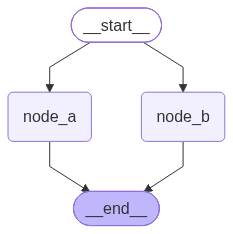

In [11]:
display(Image(graph_b.get_graph().draw_mermaid_png()))

### 12. Run it

Expect `log` to contain **both** entries — `"node_a ran"` and `"node_b ran"` — in some
order. That's `operator.add` combining two parallel writes instead of one silently
overwriting the other.

In [12]:
result = graph_b.invoke({"log": []})
print(result["log"])

['node_a ran', 'node_b ran']


## Next steps

That's the whole pattern: define a `State`, pick a reducer for each field that might
get written more than once per step, write nodes that return partial updates, and wire
them together with `add_node` / `add_edge`.

From here, `1_Agentic_RAG.ipynb` adds tools, a retriever, and a routing node that
decides whether to call a tool or finish — same building blocks, just more of them.